In [14]:
import sys
import pandas as pd
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"

sys.path.append(str(PROJECT_DIR))

import utils
import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

tf_dna_model_checkpoints = {
    # "mESC": CHKPT_DIR / "tf_dna_mm10_3682785" / "epoch=05-val_auroc=0.9765-val_loss=0.1653.ckpt",
    "mESC": CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt",
    "iPSC": CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt",
    "Macrophage": CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"
}

# tf_tg_model_checkpoints = {
#     "mESC": {
#         "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3686390" / "epoch=47-val_auroc=0.6560-val_loss=0.6156.ckpt",
#         "E8.5_rep1": CHKPT_DIR / "mESC" / "E8.5_rep1" / "tf_tg_train_E8.5_rep1_3675640" / "epoch=13-val_auroc=0.7088-val_loss=0.6206.ckpt"
#     },
#     "iPSC": {
#         "WT_D13_rep1": CHKPT_DIR / "iPSC" /"WT_D13_rep1" / "tf_tg_train_WT_D13_rep1_3683642" / "epoch=75-val_auroc=0.7784-val_loss=0.5489.ckpt",
#     },
#     "Macrophage": {
#         "buffer_1": CHKPT_DIR / "Macrophage" / "buffer_1" / "tf_tg_train_buffer_1_3685893" / "epoch=152-val_auroc=0.8552-val_loss=0.4733.ckpt",
#         "buffer_2": CHKPT_DIR / "Macrophage" / "buffer_2" / "tf_tg_train_buffer_2_3685903" / "epoch=53-val_auroc=0.7698-val_loss=0.5434.ckpt",
#     }
# }

### Load the latest model checkpoints for each sample

In [ ]:
def find_latest_checkpoint(cell_type, sample_name):
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
        
    slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: {latest_chkpt_file}")
    return latest_chkpt_file
    
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": find_latest_checkpoint("mESC", "E7.5_rep1"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1")
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep1: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/checkpoints/mESC/E7.5_rep1/tf_tg_train_E7.5_rep1_3686390/epoch=47-val_auroc=0.6560-val_loss=0.6156.ckpt
WARNING - No checkpoint files found for E8.5_rep1 in /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/checkpoints/mESC/E8.5_rep1/tf_tg_train_E8.5_rep1_3691937
INFO - Latest checkpoint for iPSC WT_D13_rep1: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/checkpoints/iPSC/WT_D13_rep1/tf_tg_train_WT_D13_rep1_3683642/epoch=75-val_auroc=0.7784-val_loss=0.5489.ckpt
INFO - Latest checkpoint for Macrophage buffer_1: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/checkpoints/Macrophage/buffer_1/tf_tg_train_buffer_1_3685893/epoch=152-val_auroc=0.8552-val_loss=0.4733.ckpt

### Function to load the trained TF-TG binding model

In [2]:
def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 3) Load the model state from the checkpoint
    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [3]:
def load_training_cache_dataset(
    sample_name: str,
    cell_type_cache_dir: Path, 
    split_type: str = "test", 
    subset_size: int = None
    ) -> DataLoader:
    
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor


### Run model predictions on the trained dataset

Model WT_D13_rep1 | Test set WT_D13_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

Model buffer_1 | Test set buffer_1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

Model buffer_2 | Test set buffer_2


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

,0,1,2
Model,WT_D13_rep1,buffer_1,buffer_2
Test Set,WT_D13_rep1,buffer_1,buffer_2
auroc,0.655911,0.827626,0.747492
auprc,0.776697,0.842383,0.6385
accuracy,0.6126,0.7368,0.704
precision,0.723198,0.757266,0.671756
recall,0.633878,0.734196,0.382609
rand_auroc,0.491958,0.491961,0.507034
rand_auprc,0.628793,0.521675,0.373977


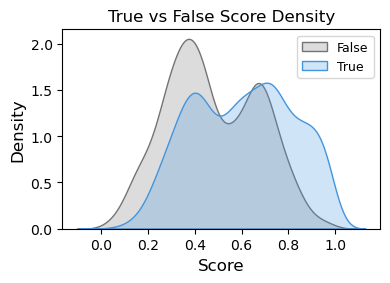

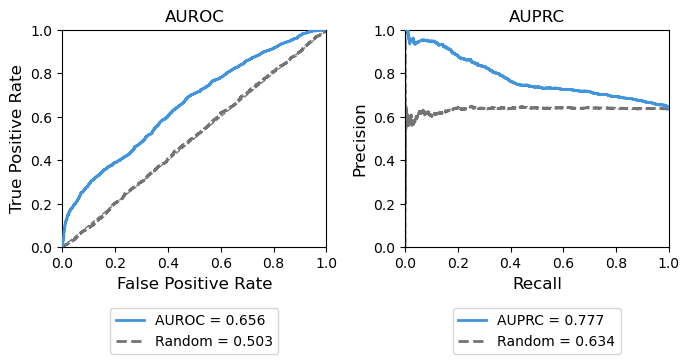

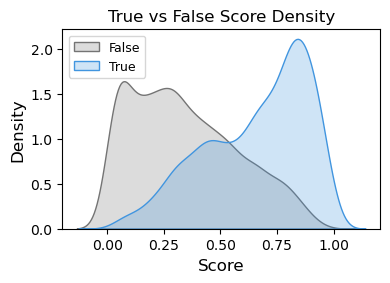

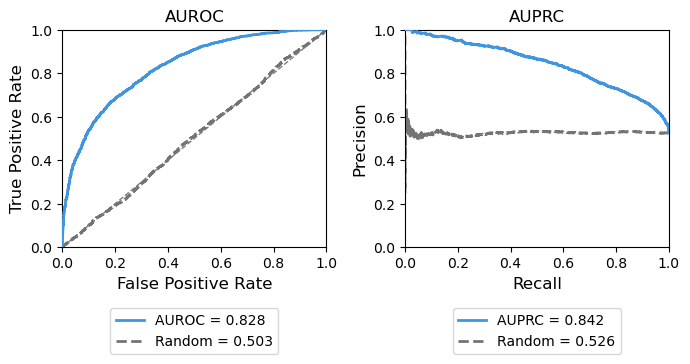

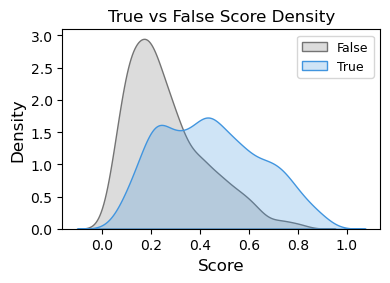

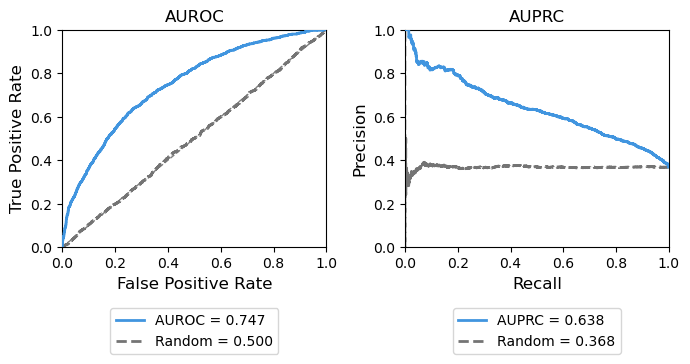

In [15]:
all_comparison_df_list = []

# evaluations = {
#     "mESC": [
#         ("E7.5_rep1", "E7.5_rep1"),
#         # ("E7.5_rep1", "E8.5_rep1"),
#         # ("E8.5_rep1", "E7.5_rep1"),
#         ("E8.5_rep1", "E8.5_rep1"),
#     ],
#     "iPSC": [
#         ("WT_D13_rep1", "buffer_2"),
#         # ("WT_D13_rep1", "buffer_2"),
#     ],
#     "Macrophage": [
#         # ("buffer_1", "buffer_1"),
#         ("buffer_2", "buffer_2"),
#     ]
# }

evaluations = [
    # ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
    # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
    ("iPSC", "WT_D13_rep1", "iPSC", "WT_D13_rep1"),
    ("Macrophage", "buffer_1", "Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2", "Macrophage", "buffer_2"),
]

# model_cell_type = "mESC"
# test_set_cell_type = "mESC"
for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in evaluations:
    print(f"Model {model_training_sample} | Test set {evaluation_sample}")
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        continue

    # print(f"Loading TF→TG model")
    dataset_split_type = "test"
    subset_size = 5000
    
    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []

    # print(f"Evaluating on {dataset_split_type} set")
    for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"]
        cell_mask = batch["cell_mask"]
        E, C = cell_mask.shape

        edge_logits, _ = model.forward(
            tf_embedding=batch["tf_embedding"],
            tf_mask=batch["tf_mask"],
            peak_sequences=batch["peak_sequences"],
            peak_accessibility=batch["peak_accessibility"],
            peak_distance=batch["peak_distance"],
            tf_expression=batch["tf_expression"],
            tg_expression=batch["tg_expression"],
            peak_mask=batch.get("peak_mask", None),
            cell_mask=cell_mask,
            pooling_mode=pooling_mode,
            pooling_temperature=pooling_temperature,
        )

        loss = criterion(edge_logits, labels)

        total_loss += loss.item() * E
        n_edges += E

        scores = torch.sigmoid(edge_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    mean_loss = total_loss / max(n_edges, 1)

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "recall", "rand_auroc", "rand_auprc"]

    metric_df = metric_df[col_order]

    all_comparison_df_list.append(metric_df)
    
    histogram_fig = plotting_utils.plot_score_histograms(
        labels=all_labels_flat,
        scores=all_scores_flat,
        n_bins=50,
        y_log=False,
        panel_kind="kde",
        density=False,
    )
    histogram_fig.show()

    auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
        labels=all_labels_flat,
        scores=all_scores_flat,
    )
    auroc_auprc_fig.show()
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df.T)

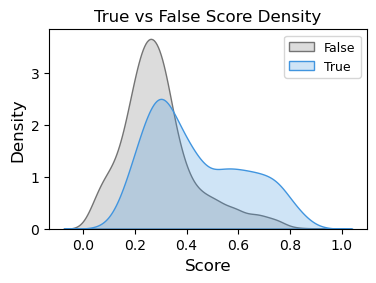

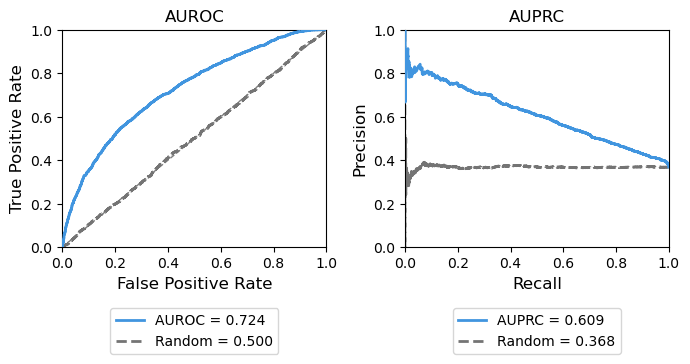

In [56]:
histogram_fig = plotting_utils.plot_score_histograms(
    labels=all_labels_flat,
    scores=all_scores_flat,
    n_bins=50,
    y_log=False,
    panel_kind="kde",
    density=False,
)
histogram_fig.show()

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
)
auroc_auprc_fig.show()

### Evaluate the predictions

In [45]:
importlib.reload(stat_utils)

<module 'stat_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/stat_utils.py'>

In [10]:
metrics = stat_utils.compute_binary_classification_metrics(
    labels=all_labels_flat,
    scores=all_scores_flat,
    score_threshold=score_threshold,
    random_state=42,
)

mean_loss = total_loss / max(n_edges, 1)

metrics["Model"] = model_training_sample
metrics["Test Set"] = evaluation_sample
metrics["loss"] = mean_loss
metrics["score_min"] = float(all_scores_flat.min())
metrics["score_max"] = float(all_scores_flat.max())
metrics["score_mean"] = float(all_scores_flat.mean())
metrics["score_std"] = float(all_scores_flat.std())
metrics["n_pred_pos"] = int((all_scores_flat >= score_threshold).sum())
metrics["n_pred_neg"] = int((all_scores_flat < score_threshold).sum())

metric_df = pd.DataFrame([metrics])

col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "rand_auroc", "rand_auprc"]

metric_df = metric_df[col_order]


all_comparison_df_list.append(metric_df)

print("Final Test Metrics:")
display(metric_df.T)

Final Test Metrics:


,0
Model,E7.5_rep1
Test Set,E7.5_rep1
auroc,0.572233
auprc,0.455054
accuracy,0.6418
precision,0.649682
rand_auroc,0.505406
rand_auprc,0.371783


In [44]:
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df)

,Model,Test Set,auroc,auprc,accuracy,precision,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.696399,0.577159,0.6708,0.698347,0.519975,0.381786
1,E7.5_rep1,E8.5_rep1,0.621752,0.629031,0.5656,0.661054,0.501131,0.519073
2,E8.5_rep1,E7.5_rep1,0.636114,0.489747,0.6294,0.493907,0.526398,0.390878
3,E8.5_rep1,E8.5_rep1,0.690027,0.686342,0.6314,0.638061,0.494796,0.520802


## Testing model sizes through the network

In [23]:
evaluation_cell_type = "mESC"
model_training_sample = "E7.5_rep1"
evaluation_sample = "E7.5_rep1"

print(f"Model {model_training_sample} | Test set {evaluation_sample}")

tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[evaluation_cell_type]

# print(f"Loading TF→TG model")
dataset_split_type = "test"
subset_size = 5000

cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

# print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=dataset_split_type,
    subset_size=subset_size
    )

tf_tg_model = load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

# print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model

Model E7.5_rep1 | Test set E7.5_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [24]:
model

TFTGRegulationModel(
  (tf_peak_model): TFPeakBindingModel(
    (tf_encoder): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_encoder): Sequential(
      (0): Conv1d(4, 64, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (9): BatchNorm1d(1

In [25]:
def shape_of(x):
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_of(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_of(v) for v in x]
    if x is None:
        return None
    return type(x).__name__


def make_shape_hook(name):
    def hook(module, args, kwargs, output):
        print(f"\n{name}")
        print(f"  args  : {shape_of(args)}")
        print(f"  kwargs: {shape_of(kwargs)}")
        print(f"  output: {shape_of(output)}")
    return hook


model = tf_tg_model.model.to(device)
model.eval()

hook_names = {
    "tf_peak_model.tf_encoder",
    "tf_peak_model.peak_encoder",
    "tf_peak_model.cross_attn",
    "tf_peak_model.classifier",
    "peak_feature_proj",
    "tf_expr_proj",
    "tg_expr_proj",
    "tg_query_proj",
    "peak_attention",
    "norm",
    "classifier",
}

# Clear old hooks aggressively in notebook debugging
for module in model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

hooks = []
for name, module in model.named_modules():
    if name in hook_names:
        hooks.append(
            module.register_forward_hook(
                make_shape_hook(name),
                with_kwargs=True,
            )
        )
        
batch = next(iter(data_loader))
batch = tf_to_tg_module.move_batch_to_device(batch, device)

print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")

with torch.no_grad():
    edge_logits, aux_outputs = model(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=batch["cell_mask"],
        pooling_mode="lse",
        pooling_temperature=1.0,
    )

print("\nFinal outputs:")
print("  edge_logits:", tuple(edge_logits.shape))
print("  aux_outputs:", shape_of(aux_outputs))

for h in hooks:
    h.remove()


Batch input shapes:
  tf_embedding: (64, 5588, 128)
  tf_mask: (64, 5588)
  peak_sequences: (64, 12, 256, 4)
  peak_accessibility: (64, 32, 12)
  peak_distance: (64, 12)
  tf_expression: (64, 32)
  tg_expression: (64, 32)
  label: (64,)
  cell_mask: (64, 32)
  peak_mask: (64, 12)

tf_peak_model.tf_encoder
  args  : [(768, 5588, 128)]
  kwargs: {}
  output: (768, 5588, 128)

tf_peak_model.peak_encoder
  args  : [(768, 4, 256)]
  kwargs: {}
  output: (768, 128, 16)

tf_peak_model.cross_attn
  args  : []
  kwargs: {'x': (768, 5588, 128), 'context': (768, 16, 128), 'mask': (768, 5588), 'context_mask': (768, 16)}
  output: [(768, 5588, 128), (768, 16, 128)]

tf_peak_model.classifier
  args  : [(768, 256)]
  kwargs: {}
  output: (768, 1)

peak_feature_proj
  args  : [(2048, 12, 4)]
  kwargs: {}
  output: (2048, 12, 128)

tf_expr_proj
  args  : [(2048, 1)]
  kwargs: {}
  output: (2048, 128)

tg_expr_proj
  args  : [(2048, 1)]
  kwargs: {}
  output: (2048, 128)

tg_query_proj
  args  : [(2048